# 04 — Association Rules Notebook

This notebook mirrors the Pattern Rules page. It converts numeric development indicators into readable bins such as `high_gdp_per_capita` or `low_infant_mortality`, then uses Apriori and FP-Growth to discover frequent patterns and rules.

## Why binning is needed

Association rules require transaction-like boolean items. Since the dataset is numeric, each indicator is converted into Low / Medium / High based on quantiles.

In [5]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATHS = [
    PROJECT_ROOT / "sample_datasets" / "world_panel_2010_2023.csv",
    PROJECT_ROOT / "data" / "raw" / "world_panel_2010_2023.csv",
    Path("sample_datasets/world_panel_2010_2023.csv"),
]
DATA_PATH = next((p for p in DATA_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find world_panel_2010_2023.csv. Put this notebook folder in the project root.")

CHARTS_DIR = PROJECT_ROOT / "charts" / Path.cwd().name.replace(" ", "_")
if Path.cwd().name != "notebooks":
    CHARTS_DIR = PROJECT_ROOT / "charts" / "04_association_rules"
PROCESSED_DIR = PROJECT_ROOT / "after_processing_dataset"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def save_mpl(name, dpi=160):
    path = CHARTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved chart: {path}")
    plt.show()

def save_df(df, name):
    path = PROCESSED_DIR / name
    df.to_csv(path, index=False)
    print(f"Saved dataset: {path}")
    return path

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head()

from sklearn.impute import SimpleImputer
try:
    from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
    MLXTEND_AVAILABLE = True
except Exception as e:
    MLXTEND_AVAILABLE = False
    print("mlxtend is not installed. Run: pip install mlxtend")

numeric_cols = df.select_dtypes(include="number").columns.tolist()
feature_cols = [c for c in numeric_cols if c != "year"]
country_profile = df.groupby(["country", "code", "region"], as_index=False)[feature_cols].mean()

Loaded: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\sample_datasets\world_panel_2010_2023.csv
Shape: (336, 22)


## 1. Convert country profiles into transactions

In [6]:
def make_quantile_transactions(data, features):
    baskets = []
    for _, row in data.iterrows():
        items = []
        for col in features:
            q1 = data[col].quantile(0.33)
            q2 = data[col].quantile(0.66)
            val = row[col]
            if val <= q1:
                label = "low"
            elif val <= q2:
                label = "medium"
            else:
                label = "high"
            items.append(f"{label}_{col}")
        baskets.append(items)
    return baskets

baskets = make_quantile_transactions(country_profile, feature_cols)
for c, b in zip(country_profile["country"].head(3), baskets[:3]):
    print(c, "=>", b[:8], "...")

Algeria => ['low_gdp_per_capita', 'low_hdi', 'low_life_expectancy', 'low_literacy_rate', 'low_internet_usage_pct', 'low_co2_per_capita', 'high_fertility_rate', 'high_infant_mortality'] ...
Australia => ['high_gdp_per_capita', 'high_hdi', 'high_life_expectancy', 'high_literacy_rate', 'high_internet_usage_pct', 'high_co2_per_capita', 'low_fertility_rate', 'low_infant_mortality'] ...
Brazil => ['medium_gdp_per_capita', 'medium_hdi', 'medium_life_expectancy', 'medium_literacy_rate', 'medium_internet_usage_pct', 'medium_co2_per_capita', 'medium_fertility_rate', 'medium_infant_mortality'] ...


In [7]:
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_matrix = te.fit(baskets).transform(baskets)
te_df = pd.DataFrame(te_matrix, columns=te.columns_)
print(te_df.shape)
display(te_df.head())
save_df(pd.concat([country_profile[["country","code","region"]], te_df], axis=1), "association_transaction_matrix.csv")

(24, 54)


,high_access_to_water_pct,high_co2_per_capita,high_education_spending_pct,high_fertility_rate,high_gdp_per_capita,high_gini_index,high_hdi,high_health_spending_pct,high_infant_mortality,high_internet_usage_pct,...,medium_infant_mortality,medium_internet_usage_pct,medium_life_expectancy,medium_literacy_rate,medium_maternal_mortality,medium_political_stability,medium_population,medium_renewable_energy_pct,medium_unemployment_rate,medium_urbanization_rate
0,False,False,False,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,True,True,True,False,True,False,True,True,False,True,...,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,False,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,True,True,False,True


Saved dataset: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\after_processing_dataset\association_transaction_matrix.csv


WindowsPath('c:/Users/moham/Desktop/World_Development_FINAL_PAGED-2/after_processing_dataset/association_transaction_matrix.csv')

## 2. Item frequency analysis

,item,support
0,high_access_to_water_pct,0.333333
1,high_co2_per_capita,0.333333
2,high_education_spending_pct,0.333333
3,high_fertility_rate,0.333333
4,high_gdp_per_capita,0.333333
5,high_gini_index,0.333333
6,high_hdi,0.333333
7,high_health_spending_pct,0.333333
8,high_infant_mortality,0.333333
9,high_internet_usage_pct,0.333333


Saved dataset: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\after_processing_dataset\association_item_support.csv
Saved chart: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\charts\notebooks\association_top_item_support.png


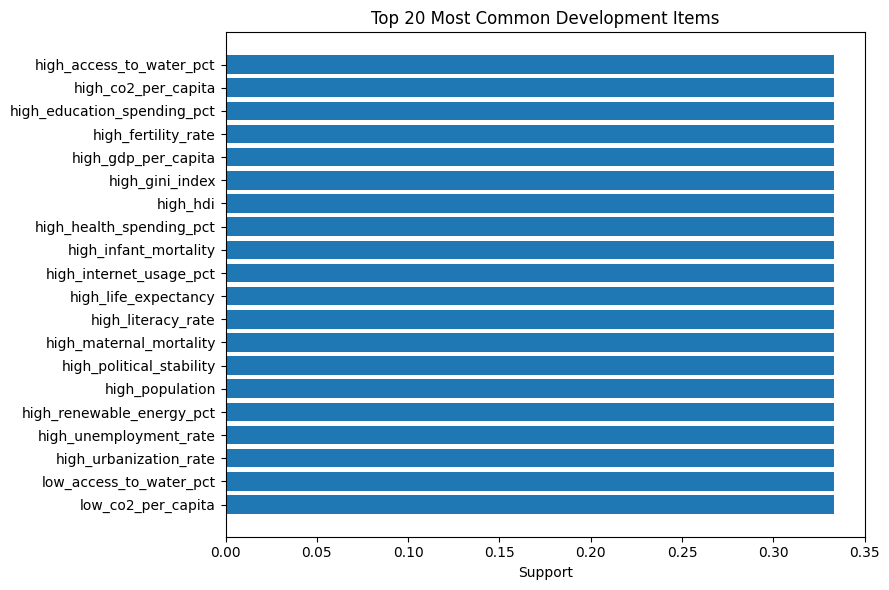

In [8]:
item_support = te_df.mean().sort_values(ascending=False).reset_index()
item_support.columns = ["item", "support"]
display(item_support.head(20))
save_df(item_support, "association_item_support.csv")

plt.figure(figsize=(9,6))
top_items = item_support.head(20).iloc[::-1]
plt.barh(top_items["item"], top_items["support"])
plt.title("Top 20 Most Common Development Items")
plt.xlabel("Support")
save_mpl("association_top_item_support.png")

## 3. Apriori frequent itemsets

In [9]:
if not MLXTEND_AVAILABLE:
    raise ImportError("Please install mlxtend: pip install mlxtend")

frequent_apriori = apriori(te_df, min_support=0.20, use_colnames=True, max_len=4)
frequent_apriori["length"] = frequent_apriori["itemsets"].apply(len)
frequent_apriori = frequent_apriori.sort_values(["support","length"], ascending=[False,False])
display(frequent_apriori.head(25))
save_df(frequent_apriori.assign(itemsets=frequent_apriori["itemsets"].astype(str)), "apriori_frequent_itemsets.csv")

,support,itemsets,length
2503,0.333333,"frozenset({high_hdi, high_access_to_water_pct,...",4
2504,0.333333,"frozenset({high_access_to_water_pct, high_educ...",4
2505,0.333333,"frozenset({high_access_to_water_pct, high_inte...",4
2506,0.333333,"frozenset({high_access_to_water_pct, high_educ...",4
2507,0.333333,"frozenset({high_literacy_rate, high_access_to_...",4
2508,0.333333,"frozenset({high_access_to_water_pct, high_poli...",4
2509,0.333333,"frozenset({high_access_to_water_pct, high_urba...",4
2510,0.333333,"frozenset({low_fertility_rate, high_access_to_...",4
2512,0.333333,"frozenset({high_access_to_water_pct, high_educ...",4
2513,0.333333,"frozenset({high_access_to_water_pct, low_mater...",4


Saved dataset: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\after_processing_dataset\apriori_frequent_itemsets.csv


WindowsPath('c:/Users/moham/Desktop/World_Development_FINAL_PAGED-2/after_processing_dataset/apriori_frequent_itemsets.csv')

Saved chart: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\charts\notebooks\apriori_itemset_lengths.png


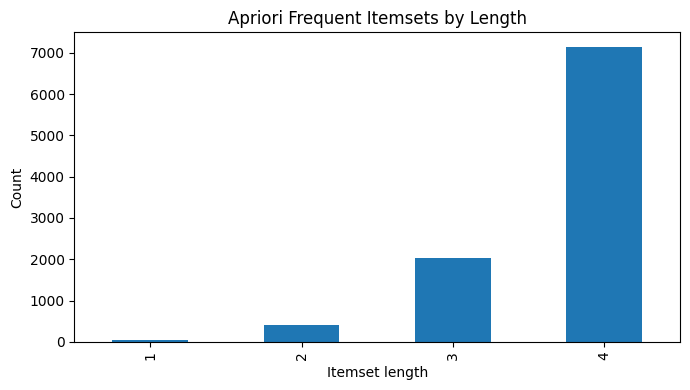

In [10]:
plt.figure(figsize=(7,4))
frequent_apriori["length"].value_counts().sort_index().plot(kind="bar")
plt.title("Apriori Frequent Itemsets by Length")
plt.xlabel("Itemset length")
plt.ylabel("Count")
save_mpl("apriori_itemset_lengths.png")

## 4. Apriori association rules

In [11]:
rules = association_rules(frequent_apriori, metric="lift", min_threshold=1.05)
rules = rules[rules["confidence"] >= 0.55].copy()
rules["If"] = rules["antecedents"].apply(lambda x: " AND ".join(sorted(list(x))))
rules["Then"] = rules["consequents"].apply(lambda x: " AND ".join(sorted(list(x))))
rules = rules.sort_values(["lift","confidence","support"], ascending=False)
display(rules[["If","Then","support","confidence","lift","leverage","conviction"]].head(30).round(4))
save_df(rules[["If","Then","support","confidence","lift","leverage","conviction"]], "apriori_association_rules.csv")

,If,Then,support,confidence,lift,leverage,conviction
107209,medium_education_spending_pct AND medium_gini_...,medium_access_to_water_pct AND medium_gdp_per_...,0.2083,1.0000,4.0,0.1562,inf
107448,medium_gini_index AND medium_health_spending_pct,medium_access_to_water_pct AND medium_gdp_per_...,0.2083,1.0000,4.0,0.1562,inf
107981,medium_education_spending_pct AND medium_gini_...,medium_co2_per_capita AND medium_gdp_per_capita,0.2083,1.0000,4.0,0.1562,inf
108218,medium_gini_index AND medium_health_spending_pct,medium_co2_per_capita AND medium_gdp_per_capita,0.2083,1.0000,4.0,0.1562,inf
108737,medium_education_spending_pct AND medium_gini_...,medium_fertility_rate AND medium_gdp_per_capita,0.2083,1.0000,4.0,0.1562,inf
108905,medium_education_spending_pct AND medium_gini_...,medium_gdp_per_capita AND medium_hdi,0.2083,1.0000,4.0,0.1562,inf
108917,medium_education_spending_pct AND medium_gini_...,medium_gdp_per_capita AND medium_health_spendi...,0.2083,1.0000,4.0,0.1562,inf
108918,medium_gini_index AND medium_health_spending_pct,medium_education_spending_pct AND medium_gdp_p...,0.2083,1.0000,4.0,0.1562,inf
108931,medium_education_spending_pct AND medium_gini_...,medium_gdp_per_capita AND medium_infant_mortality,0.2083,1.0000,4.0,0.1562,inf
108945,medium_education_spending_pct AND medium_gini_...,medium_gdp_per_capita AND medium_internet_usag...,0.2083,1.0000,4.0,0.1562,inf


Saved dataset: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\after_processing_dataset\apriori_association_rules.csv


WindowsPath('c:/Users/moham/Desktop/World_Development_FINAL_PAGED-2/after_processing_dataset/apriori_association_rules.csv')

Saved chart: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\charts\notebooks\apriori_support_confidence_lift.png


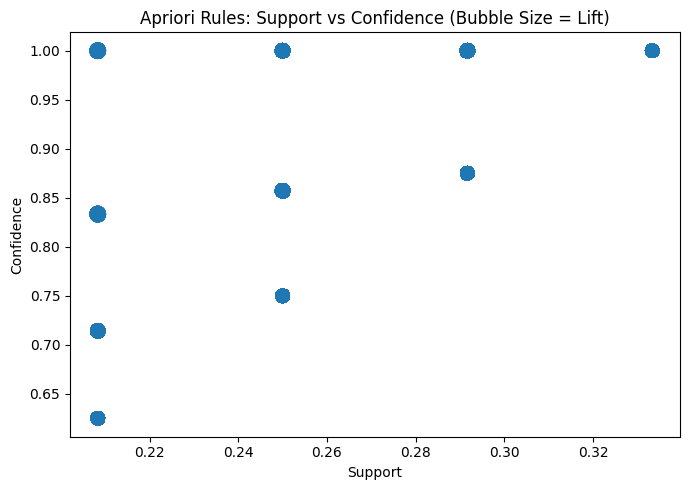

Saved chart: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\charts\notebooks\apriori_top_rules_by_lift.png


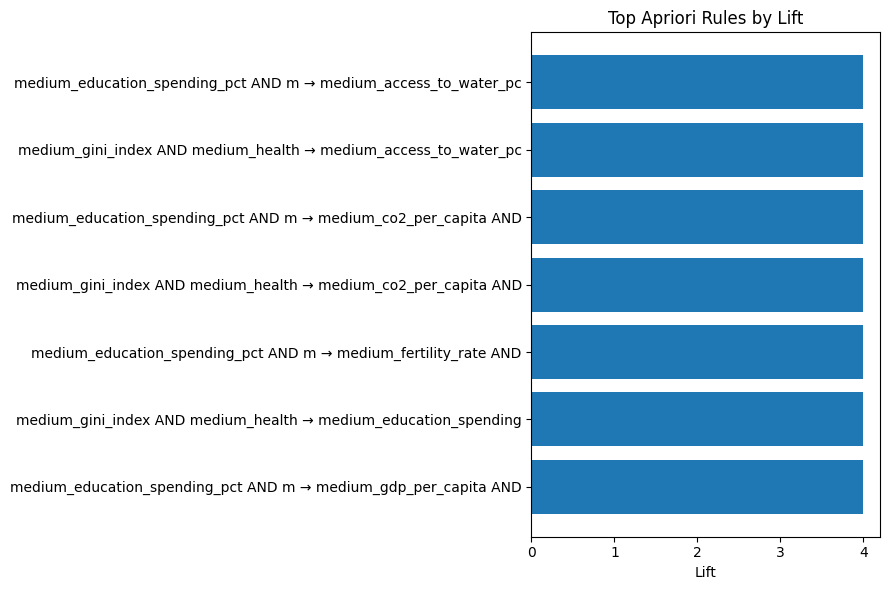

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(rules["support"], rules["confidence"], s=rules["lift"]*30, alpha=0.7)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Apriori Rules: Support vs Confidence (Bubble Size = Lift)")
save_mpl("apriori_support_confidence_lift.png")

plt.figure(figsize=(9,6))
top_rules = rules.head(15).copy()
top_rules["rule"] = top_rules["If"].str[:35] + " → " + top_rules["Then"].str[:25]
plt.barh(top_rules["rule"].iloc[::-1], top_rules["lift"].iloc[::-1])
plt.xlabel("Lift")
plt.title("Top Apriori Rules by Lift")
save_mpl("apriori_top_rules_by_lift.png")

## 5. FP-Growth comparison

FP-Growth is not required in the page, but it is useful for the notebook because it shows another frequent-pattern method and lets you compare with Apriori.

In [13]:
frequent_fp = fpgrowth(te_df, min_support=0.20, use_colnames=True, max_len=4)
frequent_fp["length"] = frequent_fp["itemsets"].apply(len)
frequent_fp = frequent_fp.sort_values(["support","length"], ascending=[False,False])
display(frequent_fp.head(25))
save_df(frequent_fp.assign(itemsets=frequent_fp["itemsets"].astype(str)), "fpgrowth_frequent_itemsets.csv")

comparison = pd.DataFrame({
    "method": ["Apriori", "FP-Growth"],
    "frequent_itemsets": [len(frequent_apriori), len(frequent_fp)],
    "max_support": [frequent_apriori["support"].max(), frequent_fp["support"].max()]
})
display(comparison)
save_df(comparison, "association_method_comparison.csv")

,support,itemsets,length
544,0.333333,"frozenset({low_urbanization_rate, low_life_exp...",4
582,0.333333,"frozenset({low_hdi, low_life_expectancy, low_i...",4
586,0.333333,"frozenset({low_hdi, low_urbanization_rate, low...",4
587,0.333333,"frozenset({low_hdi, low_urbanization_rate, low...",4
588,0.333333,"frozenset({low_hdi, low_urbanization_rate, low...",4
689,0.333333,"frozenset({low_co2_per_capita, low_hdi, low_li...",4
693,0.333333,"frozenset({low_co2_per_capita, low_life_expect...",4
694,0.333333,"frozenset({low_co2_per_capita, low_hdi, low_li...",4
695,0.333333,"frozenset({low_co2_per_capita, low_hdi, low_in...",4
700,0.333333,"frozenset({low_co2_per_capita, low_urbanizatio...",4


Saved dataset: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\after_processing_dataset\fpgrowth_frequent_itemsets.csv


,method,frequent_itemsets,max_support
0,Apriori,9642,0.333333
1,FP-Growth,9642,0.333333


Saved dataset: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\after_processing_dataset\association_method_comparison.csv


WindowsPath('c:/Users/moham/Desktop/World_Development_FINAL_PAGED-2/after_processing_dataset/association_method_comparison.csv')

## 6. Human-readable interpretation

In [14]:
for i, (_, r) in enumerate(rules.head(10).iterrows(), start=1):
    print(f"Rule {i}: IF {r['If']} THEN {r['Then']} | support={r.support:.2f}, confidence={r.confidence:.2f}, lift={r.lift:.2f}")

Rule 1: IF medium_education_spending_pct AND medium_gini_index THEN medium_access_to_water_pct AND medium_gdp_per_capita | support=0.21, confidence=1.00, lift=4.00
Rule 2: IF medium_gini_index AND medium_health_spending_pct THEN medium_access_to_water_pct AND medium_gdp_per_capita | support=0.21, confidence=1.00, lift=4.00
Rule 3: IF medium_education_spending_pct AND medium_gini_index THEN medium_co2_per_capita AND medium_gdp_per_capita | support=0.21, confidence=1.00, lift=4.00
Rule 4: IF medium_gini_index AND medium_health_spending_pct THEN medium_co2_per_capita AND medium_gdp_per_capita | support=0.21, confidence=1.00, lift=4.00
Rule 5: IF medium_education_spending_pct AND medium_gini_index THEN medium_fertility_rate AND medium_gdp_per_capita | support=0.21, confidence=1.00, lift=4.00
Rule 6: IF medium_education_spending_pct AND medium_gini_index THEN medium_gdp_per_capita AND medium_hdi | support=0.21, confidence=1.00, lift=4.00
Rule 7: IF medium_education_spending_pct AND medium_g